The assignment consists of multiple phases, including data preprocessing, exploratory data analysis (EDA), feature engineering, predictive modeling, and reporting. Below is the detailed solution for each phase.

---

### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

#### **Step 1: Data Import and Preprocessing**


In [211]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Load the dataset
file_path = 'Food_Delivery_Time_Prediction.csv'
data = pd.read_csv(file_path)

In [212]:

# Display basic information
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [213]:

# Handle missing values
if data.isnull().sum().sum() > 0:
    data.fillna(data.median(numeric_only=True), inplace=True)

# Display the first few rows
print(data.head())

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 



**Handling Categorical Variables:**


In [214]:

# Label Encoding for ordinal variables
label_enc = LabelEncoder()
data['Order_Priority'] = label_enc.fit_transform(data['Order_Priority'])


In [215]:
# One-hot encoding categorical variables
categorical_columns = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Time']
X = pd.get_dummies(data.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time'], axis=1),
                   columns=categorical_columns, drop_first=True)

# Confirm all features are now numeric
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Distance                    200 non-null    float64
 1   Delivery_Person_Experience  200 non-null    int64  
 2   Order_Priority              200 non-null    int32  
 3   Restaurant_Rating           200 non-null    float64
 4   Customer_Rating             200 non-null    float64
 5   Order_Cost                  200 non-null    float64
 6   Tip_Amount                  200 non-null    float64
 7   Weather_Conditions_Rainy    200 non-null    bool   
 8   Weather_Conditions_Snowy    200 non-null    bool   
 9   Weather_Conditions_Sunny    200 non-null    bool   
 10  Traffic_Conditions_Low      200 non-null    bool   
 11  Traffic_Conditions_Medium   200 non-null    bool   
 12  Vehicle_Type_Bike           200 non-null    bool   
 13  Vehicle_Type_Car            200 non

In [216]:

# # One-Hot Encoding for nominal variables
# categorical_columns = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']
# data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [217]:
# data.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location'], axis=1, inplace=True)
# print(data.dtypes)

In [218]:
# Normalize numerical features
scaler = StandardScaler()
numerical_columns = ['Distance', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])


---

#### **Step 2: Exploratory Data Analysis (EDA)**

**Descriptive Statistics:**

In [219]:
# Summary statistics
print(data.describe())


           Distance  Delivery_Person_Experience  Order_Priority  \
count  2.000000e+02                  200.000000      200.000000   
mean  -1.643130e-16                    5.250000        1.045000   
std    1.002509e+00                    2.745027        0.791268   
min   -1.608593e+00                    1.000000        0.000000   
25%   -7.924313e-01                    3.000000        0.000000   
50%   -1.806765e-01                    5.000000        1.000000   
75%    7.325599e-01                    8.000000        2.000000   
max    1.963762e+00                   10.000000        2.000000   

       Restaurant_Rating  Customer_Rating  Delivery_Time    Order_Cost  \
count         200.000000       200.000000   2.000000e+02  2.000000e+02   
mean            3.738500         3.686500   3.730349e-16 -2.042810e-16   
std             0.703021         0.697063   1.002509e+00  1.002509e+00   
min             2.500000         2.600000  -1.857269e+00 -1.688954e+00   
25%             3.200000  

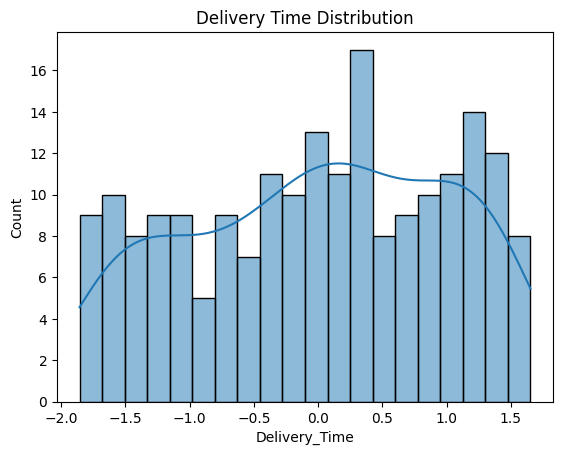

In [220]:

# Distribution of Delivery_Time
sns.histplot(data['Delivery_Time'], kde=True, bins=20)
plt.title('Delivery Time Distribution')
plt.show()




**Correlation Analysis:**

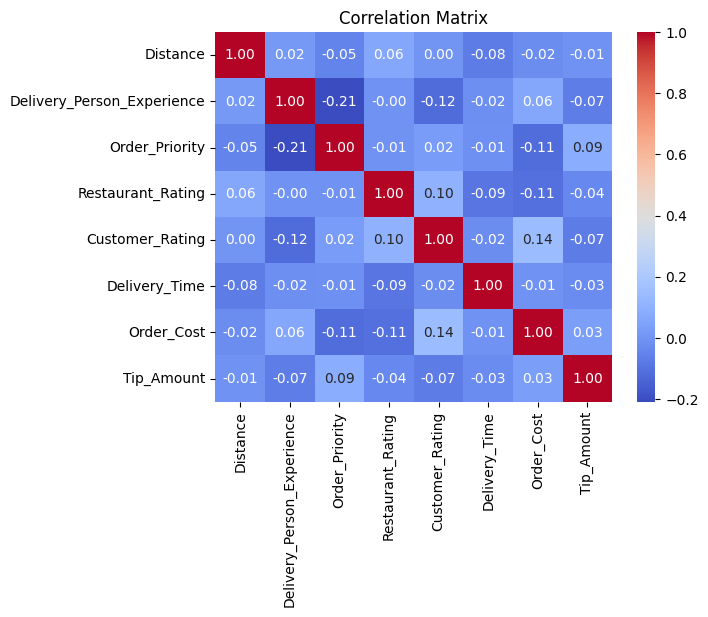

In [221]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()



**Outlier Detection:**

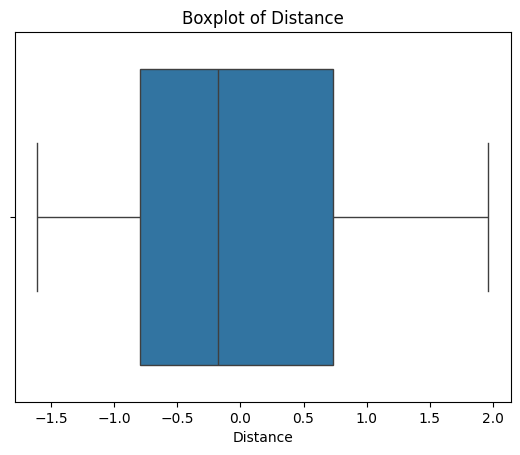

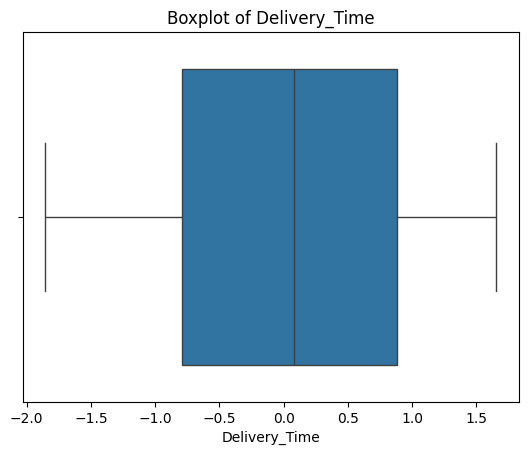

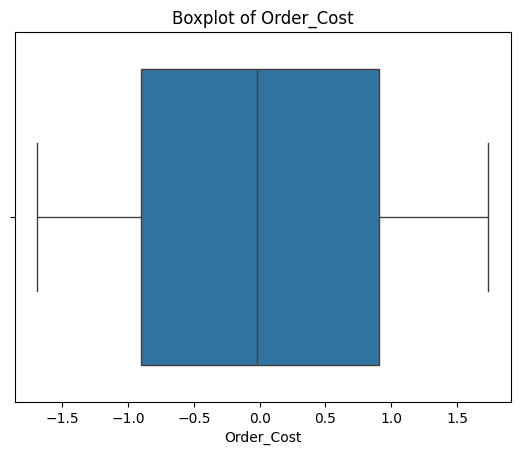

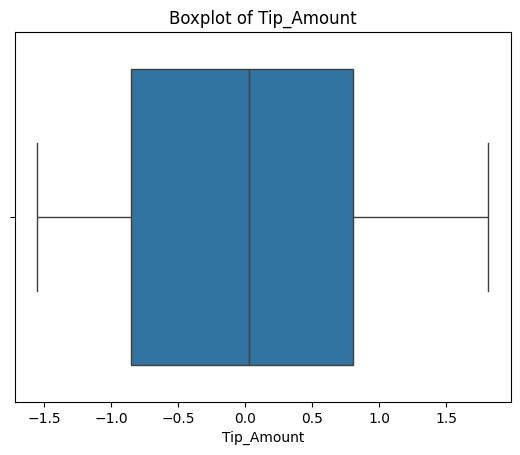

In [222]:

# Boxplot for outlier detection
for col in numerical_columns:
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


#### **Step 3: Feature Engineering**

**Distance Calculation Using Haversine Formula:**

In [223]:

from math import radians, sin, cos, sqrt, atan2

def haversine(coord1, coord2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1 = map(radians, map(float, coord1.strip('()').split(',')))
    lat2, lon2 = map(radians, map(float, coord2.strip('()').split(',')))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

data['Calculated_Distance'] = data.apply(lambda row: haversine(row['Customer_Location'], row['Restaurant_Location']), axis=1)




---

### **Phase 2: Predictive Modeling**

#### **Step 4: Linear Regression Model**



In [224]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature-target split
# X = data.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Time'], axis=1)
y = data['Delivery_Time']

In [225]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [226]:
# # Feature-target split
# X = data.drop('Delivery_Time', axis=1)
# y = data['Delivery_Time']

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Linear Regression Model
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)

# # Predictions and Evaluation
# y_pred = lr_model.predict(X_test)
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("R²:", r2_score(y_test, y_pred))


In [227]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [228]:

# Predictions and evaluation
y_pred = lr_model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 1.1517547378698243
MAE: 0.9087911209700532
R²: -0.10260297421994635




---

#### **Step 5: Logistic Regression Model**


In [229]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binarize target variable
y_class = (y < y.median()).astype(int)  

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [230]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)
# log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

LogisticRegression(max_iter=1000)

In [231]:

# Predictions and Evaluation
y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.4
Precision: 0.35294117647058826
Recall: 0.3157894736842105
F1 Score: 0.3333333333333333




**Confusion Matrix:**


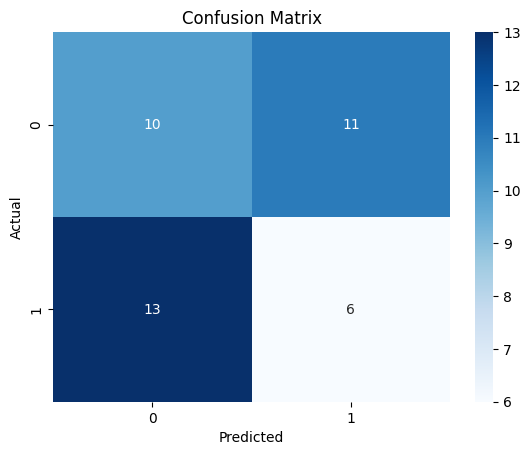

In [232]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



---

### **Phase 3: Reporting and Insights**

#### **Step 6: Model Evaluation and Comparison**


In [233]:
# Ensure X_test is scaled and matches training structure
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

Linear Regression Metrics:
MSE: 0.45396571970750693
R²: -0.8204139136140631


In [234]:

print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))


Logistic Regression Metrics:
Accuracy: 0.4


------

In [235]:
#  Ridge Regression 
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)  # Try different alpha values
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 0.28646071025809783
R²: -0.1487146276013951


In [236]:
# GridSearchCV for Logistic Regression
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
log_reg_grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
log_reg_grid.fit(X_train, y_train)
print("Best Parameters:", log_reg_grid.best_params_)
y_pred = log_reg_grid.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'C': 10, 'solver': 'liblinear'}
Accuracy: 0.4


In [237]:
#  Data Imbalance Handling
log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.35


In [238]:
# Random Forest Regression (for continuous target
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 0.305125
R²: -0.22355889724310796


In [239]:
#  XGBoost/LightGBM
from xgboost import XGBRegressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.40492870426868527


In [240]:
#  Cross-Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ridge, X, y, cv=5, scoring='neg_mean_squared_error')
print("Cross-validation MSE:", -scores.mean())

Cross-validation MSE: 1.1703985307012965


------